In [1]:
!pip install ipywidgets scikit-network --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [3]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_15253/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_15253/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


In [4]:
data = data.drop(data[data["position"] == "team"].index) 

In [5]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = data[data["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data.drop(games_with_missing_playerids.index)


there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


In [6]:
uniq_player_ids = data["playerid"].unique()
print(len(uniq_player_ids))
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_index_to_playerid = dict(zip(range(len(uniq_player_ids)), uniq_player_ids))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

2567


In [7]:
# For each playerid, print the number of different leagues they played in:
data.groupby("playerid")["league"].nunique().value_counts()

league
1    1536
2     653
3     257
4      92
5      27
6       2
Name: count, dtype: int64

In [8]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/9691 [00:00<?, ?it/s]

In [9]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

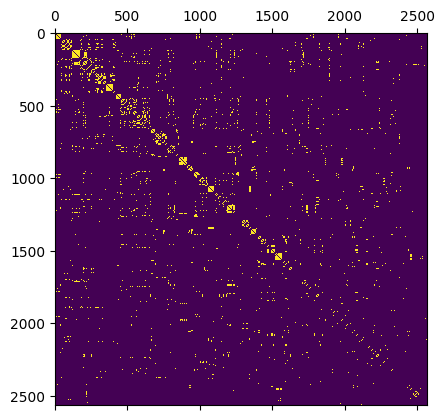

In [10]:
plt.matshow(adj_matrix)

In [15]:
#clustering = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=8)

from sknetwork.clustering import Louvain
louvain = Louvain()
clustering = louvain.fit_predict(adj_matrix)

15
Cluster 0: 355 players
Cluster 1: 349 players
Cluster 2: 221 players
Cluster 3: 209 players
Cluster 4: 193 players
Cluster 5: 188 players
Cluster 6: 174 players
Cluster 7: 157 players
Cluster 8: 153 players
Cluster 9: 131 players
Cluster 10: 121 players
Cluster 11: 95 players
Cluster 12: 94 players
Cluster 13: 73 players
Cluster 14: 54 players


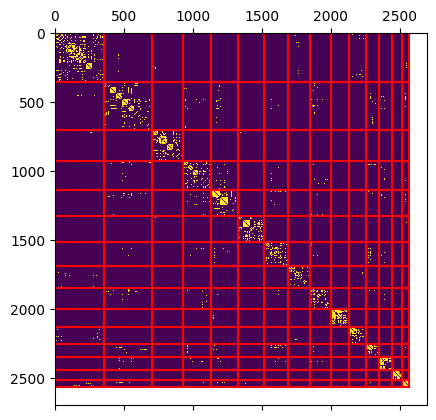

nmi_regions: 0.559922335107146
nmi_continents: 0.5284852124123122
nmi_leagues: 0.7893779679259361


In [16]:
from utils.visualize import plot_adj_matrix_sorted_by_clustering
from utils.score import nmi_regions, nmi_continents, nmi_leagues

plot_adj_matrix_sorted_by_clustering(adj_matrix, clustering)
print("nmi_regions:", nmi_regions(clustering, uniq_player_ids, data))
print("nmi_continents:", nmi_continents(clustering, uniq_player_ids, data))
print("nmi_leagues:", nmi_leagues(clustering, uniq_player_ids, data))

/tmp/ipykernel_15253/549849013.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_labels = plt.cm.get_cmap('tab10', len(np.unique(clustering)))(clustering)
/tmp/ipykernel_15253/549849013.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_labels = plt.cm.get_cmap('tab10', 8)(clustering)


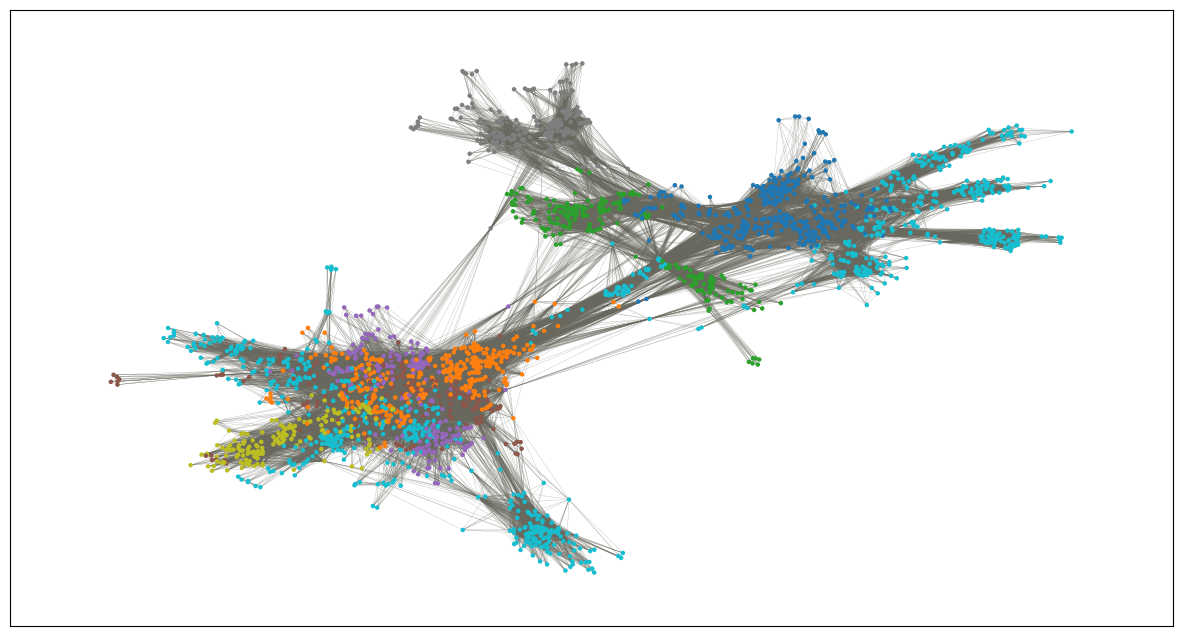

In [17]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
color_labels = plt.cm.get_cmap('tab10', len(np.unique(clustering)))(clustering)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")